In [ ]:
from nilearn.maskers import NiftiMasker
from nilearn import image
import numpy as np

brain_file= '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/REST_SES01/arREST_REST_3.4x3.4x4_20220304142158_7.nii'
seed_file= '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/roi/roi1_HIP_R/SEED1_ROIEPI.nii'

brain_masker = NiftiMasker(mask_strategy='epi', standardize='zscore_sample', detrend=False)
seed_masker = NiftiMasker(standardize='zscore_sample', detrend=False)

brain_ts = brain_masker.fit_transform(brain_file) 
seed_ts = seed_masker.fit_transform(seed_file)


computed_mask_img = seed_masker.mask_img_

# d_first_epi = image.index_img(brain_file, 0)
# plotting.plot_roi(
#     roi_img=computed_mask_img,       # 你要檢查的二進位遮罩 (紅色半透明)
#     bg_img=d_first_epi,                  # 背景底圖：原始 fMRI 影像
#     title="NiftiMasker (mask_strategy='epi') Quality Check",
#     display_mode='ortho',             # 顯示經典的正交三視圖
#     draw_cross=True,                  # 畫出中心十字線
#     cmap='Oranges'                    # 遮罩顏色 (橘/紅)
# )

# # 5. 顯示圖表
# plt.show()



ValueError: File not found: '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC071/nii/ses02/roi/roi1_HIP_R/SEED1_ROIEPI.nii'

In [ ]:
print("EPI :", brain_ts.shape)
# 預期輸出範例: (a, c) -> a 個時間點，全腦有 c 個有效 Voxels

print("Seed :", seed_ts.shape)
# 預期輸出範例: (a, b) -> a 個時間點，你的 ROI 範圍內有 b 個 Voxels

全腦矩陣大小: (260, 24086)
Seed 矩陣大小: (260, 2)


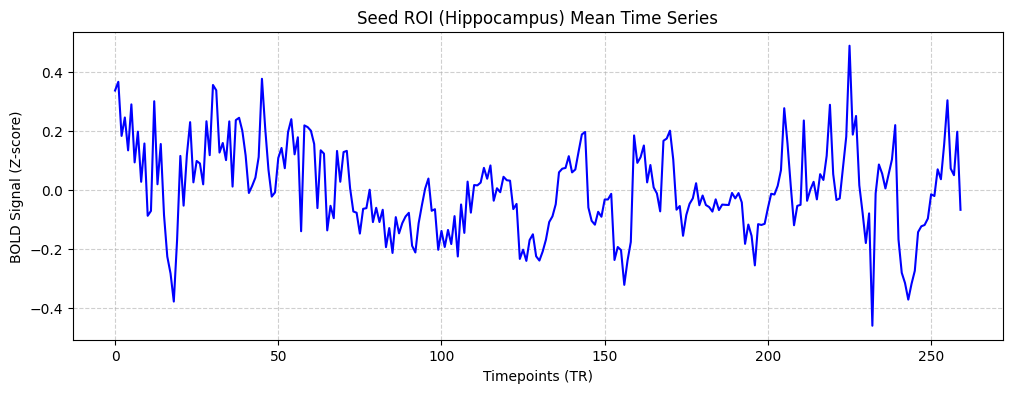

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 沿著 Voxel 軸 (axis=1) 計算平均，把 2D 矩陣變成 1D 向量
seed_1d = np.mean(brain_ts, axis=1)

# 2. 畫出折線圖
plt.figure(figsize=(12, 4))
plt.plot(seed_1d, color='blue', linewidth=1.5)
plt.title("Seed ROI (Hippocampus) Mean Time Series")
plt.xlabel("Timepoints (TR)")
plt.ylabel("BOLD Signal (Z-score)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [3]:
seed_1d = np.mean(seed_ts, axis=1)
seed_to_voxel_correlations = (np.dot(brain_ts.T, seed_1d) / seed_1d.shape[0])
seed_to_voxel_correlations_img = brain_masker.inverse_transform(seed_to_voxel_correlations.T)

output_filename = 'NTUSEC008_Seed1_FC_map2.nii'
seed_to_voxel_correlations_img.to_filename(output_filename)

# print("TS:", seed_ts.shape)
# print("1D:", seed_1d.shape)
# print("A:", seed_to_voxel_correlations.shape)
# print("IMG:", seed_to_voxel_correlations_img.shape)
threshold = 0.5
# plotting.plot_stat_map(seed_to_voxel_correlations_img, threshold=threshold, title=f"Seed based correlation")
# plt.show()

In [4]:
import numpy as np


# 2. 補上這兩行：限制極端值並轉換為 z 值
seed_to_voxel_correlations = np.clip(seed_to_voxel_correlations, -0.999, 0.999) 
fisher_z_scores = np.arctanh(seed_to_voxel_correlations)

# 3. 把 z 值填回 3D 空間！這才是準備好做統計的圖
seed_to_voxel_ZZZ_correlations_img = brain_masker.inverse_transform(fisher_z_scores.T)

/tmp/ipykernel_3515686/1368456078.py:8: UserWarning: Casting data from int16 to float32
  plotting.plot_stat_map(


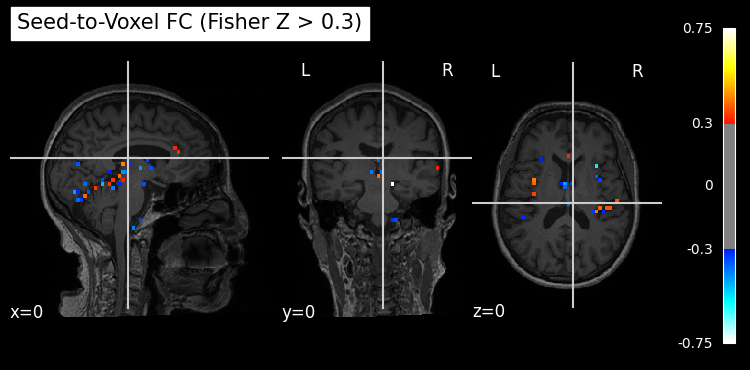

In [7]:
from nilearn import plotting
import matplotlib.pyplot as plt

d_mean_epi="/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/T1/T1_t1_mprage_sag_p2_iso_20220304142158_2.nii"

# 視覺化剛剛算出來的 FC Map
# 假設你已經用 mean_img 算出了 3d_mean_epi 當作底圖 (參考先前的腳本)
plotting.plot_stat_map(
    stat_map_img=seed_to_voxel_ZZZ_correlations_img, 
    bg_img=d_mean_epi,     # 你的 3D EPI 平均底圖
    threshold=0.3,          # 視覺化門檻：只顯示 Fisher Z 值大於 0.2 或小於 -0.2 的強連結區域
    title="Seed-to-Voxel FC (Fisher Z > 0.3)",
    display_mode='ortho',
    cut_coords=(0, 0, 0),   # 你可以改成你海馬迴 Seed 的大約 MNI 座標
    cmap='cold_hot'
)

plt.show()

In [ ]:
import nibabel as nib
import numpy as np
from nilearn import image


zmap_img = image.load_img('/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/roi/roi1_HIP_R/NTUSEC008ZMAP1.nii')      # 形狀: (X, Y, Z, Volumes)
seed_img = image.load_img('/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/roi/roi1_HIP_R/rNTUSEC008ROI1.nii')      # 形狀: (X, Y, Z)

zmap_data = zmap_img.get_fdata()
seed_data = seed_img.get_fdata()

mask_3d = (seed_data <= 0)


masked_zmap_data = zmap_data * mask_3d

# 3. 存檔 (注意：這是一張 3D 影像喔)
output_filename="/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/roi/roi1_HIP_R/ZMAP-SEED.nii"
new_img = nib.Nifti1Image(masked_zmap_data, zmap_img.affine, zmap_img.header)
new_img.to_filename(output_filename)

In [8]:
# 💡 修正關鍵：只要是不等於 0 的地方，都算作是 Seed 區域
seed_indices = (seed_data != 0)

# 重新撈取數值
values_in_seed_region = masked_zmap_data[seed_indices]

# 檢查一下到底抓到了幾個 Voxel（順便品管）
print(f"總共在 Seed 遮罩中抓到了 {len(values_in_seed_region)} 個 Voxel。")

# 如果長度大於 0，才進行極值計算，防止再次報錯
if len(values_in_seed_region) > 0:
    max_val = values_in_seed_region.max()
    min_val = values_in_seed_region.min()
    mean_val = values_in_seed_region.mean()

    print("📊 --- SEED 區域數值驗證報告 ---")
    print(f"最大值 (Max): {max_val}")
    print(f"最小值 (Min): {min_val}")
    print(f"平均值 (Mean): {mean_val}")

    if np.all(values_in_seed_region == 0):
        print("🎉 完美！驗證通過：SEED 區域內的所有 Voxel 已 100% 變為 0！")
    else:
        print("❌ 警告：SEED 區域內還有殘留非 0 的數值！")
else:
    print("❌ 嚴重警告：用 (seed_data != 0) 依然抓不到任何 Voxel，請檢查你的 seed_file 影像是不是全黑的空檔案！")

總共在 Seed 遮罩中抓到了 2 個 Voxel。
📊 --- SEED 區域數值驗證報告 ---
最大值 (Max): 0.0
最小值 (Min): 0.0
平均值 (Mean): 0.0
🎉 完美！驗證通過：SEED 區域內的所有 Voxel 已 100% 變為 0！


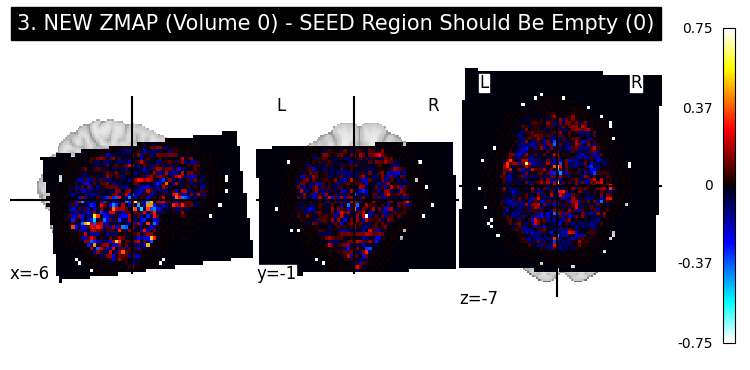

In [10]:

import matplotlib.pyplot as plt
from nilearn import plotting, image


# =========================================================================
# 圖三：檢查挖空後的 NEW_IMG (差集結果)
# =========================================================================
plotting.plot_stat_map(
    stat_map_img=zmap_img,

    title="3. NEW ZMAP (Volume 0) - SEED Region Should Be Empty (0)",


    cmap='cold_hot'
)

# 顯示所有圖片
plt.show()
